## SETUP

In [11]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_ensemble_shared_backbone
from breast_cancer.utils import get_save_path
from breast_cancer.utils.plots import plot_history

In [12]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_ensemble_shared.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [14]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [15]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [16]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [17]:
EPOCHS = 80

## MODEL STARTING POINT

In [18]:
from tensorflow.keras.applications import EfficientNetV2S

# Build backbone from pretrained model
new_cfg = model_cfg["base_model_args"].copy()
backbone = EfficientNetV2S(**model_cfg["base_model_args"])

# Build model from spec
model_cfg["model_args"]["name"] = f"ensemble_{backbone.name}"
model = build_ensemble_shared_backbone(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

82420632/82420632 [==============================] - 3s 0us/step
Model: "ensemble_efficientnetv2-s"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 efficientnetv2-s (Functional)  (None, 8, 8, 1280)   20331360    ['input_2[0][0]']                
                                                                                                  
 transition_layer (GlobalAverag  (None, 1280)        0           ['efficientnetv2-s[0][0]']       
 ePooling2D)                                                                                      
         

## MODEL EXPLORATION

#### Split by Image ID

In [19]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [20]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [21]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("efficientnetv2-s")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [22]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-22 01:20:33.911149: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-22 01:20:33.924308: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:20:33.925656: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:20:33.925666: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-22 01:20:33.926011: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-22 01:20:33.926052: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-22 01:20:33.998270: I tensorflow/stream_executor/cuda/c

1289/1289 [==============================] - 30s 18ms/step - loss: 0.7070 - auc: 0.6796 - binary_accuracy: 0.6586 - precision: 0.6104 - recall: 0.4764 - val_loss: 0.7614 - val_auc: 0.5086 - val_binary_accuracy: 0.5777 - val_precision: 0.2000 - val_recall: 0.0085 - lr: 1.0000e-04
Epoch 2/80
1289/1289 [==============================] - 18s 14ms/step - loss: 0.7157 - auc: 0.6540 - binary_accuracy: 0.6364 - precision: 0.5786 - recall: 0.4360 - val_loss: 0.7594 - val_auc: 0.5009 - val_binary_accuracy: 0.5759 - val_precision: 0.2308 - val_recall: 0.0127 - lr: 1.0000e-04
Epoch 3/80
1289/1289 [==============================] - 18s 14ms/step - loss: 0.7065 - auc: 0.6623 - binary_accuracy: 0.6460 - precision: 0.5995 - recall: 0.4270 - val_loss: 0.7505 - val_auc: 0.5138 - val_binary_accuracy: 0.5777 - val_precision: 0.2000 - val_recall: 0.0085 - lr: 1.0000e-04
Epoch 4/80
1289/1289 [==============================] - 18s 14ms/step - loss: 0.6950 - auc: 0.6784 - binary_accuracy: 0.6500 - precision: 

In [23]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
   8/1289 [..............................] - ETA: 21s - loss: 0.5913 - auc: 0.0000e+00 - binary_accuracy: 0.8828 - precision: 0.0000e+00 - recall: 0.0000e+00

1289/1289 [==============================] - 18s 14ms/step - loss: 0.6833 - auc: 0.5351 - binary_accuracy: 0.5840 - precision: 0.4771 - recall: 0.0896 - val_loss: 0.6833 - val_auc: 0.5079 - val_binary_accuracy: 0.5881 - val_precision: 0.5000 - val_recall: 0.0339 - lr: 1.0000e-05
Epoch 2/80
1289/1289 [==============================] - 18s 14ms/step - loss: 0.6913 - auc: 0.4981 - binary_accuracy: 0.5726 - precision: 0.3980 - recall: 0.0704 - val_loss: 0.6832 - val_auc: 0.5214 - val_binary_accuracy: 0.5881 - val_precision: 0.5000 - val_recall: 0.0339 - lr: 1.0000e-05
Epoch 3/80
1289/1289 [==============================] - 18s 14ms/step - loss: 0.6867 - auc: 0.5165 - binary_accuracy: 0.5811 - precision: 0.4555 - recall: 0.0794 - val_loss: 0.6834 - val_auc: 0.5134 - val_binary_accuracy: 0.5881 - val_precision: 0.5000 - val_recall: 0.0339 - lr: 1.0000e-05
Epoch 4/80
1289/1289 [==============================] - 19s 15ms/step - loss: 0.6787 - auc: 0.5531 - binary_accuracy: 0.5984 - precision: 

In [24]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  31/1289 [..............................] - ETA: 19s - loss: 0.5661 - auc: 0.0000e+00 - binary_accuracy: 0.9254 - precision: 0.0000e+00 - recall: 0.0000e+00

1289/1289 [==============================] - 21s 16ms/step - loss: 0.6865 - auc: 0.5099 - binary_accuracy: 0.5777 - precision: 0.4329 - recall: 0.0767 - val_loss: 0.6826 - val_auc: 0.5058 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 5.9030e-08
Epoch 2/80
1289/1289 [==============================] - 20s 16ms/step - loss: 0.6856 - auc: 0.5169 - binary_accuracy: 0.5791 - precision: 0.4370 - recall: 0.0710 - val_loss: 0.6826 - val_auc: 0.5037 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 5.9030e-08
Epoch 3/80
1289/1289 [==============================] - 22s 17ms/step - loss: 0.6871 - auc: 0.5077 - binary_accuracy: 0.5784 - precision: 0.4359 - recall: 0.0748 - val_loss: 0.6827 - val_auc: 0.5081 - val_binary_accuracy: 0.5881 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 5.9030e-08
Epoch 4/80
1288/1289 [============================>.] - ETA: 0s - loss: 0.6846 - auc: 0.5198 - binary_accuracy: 0.

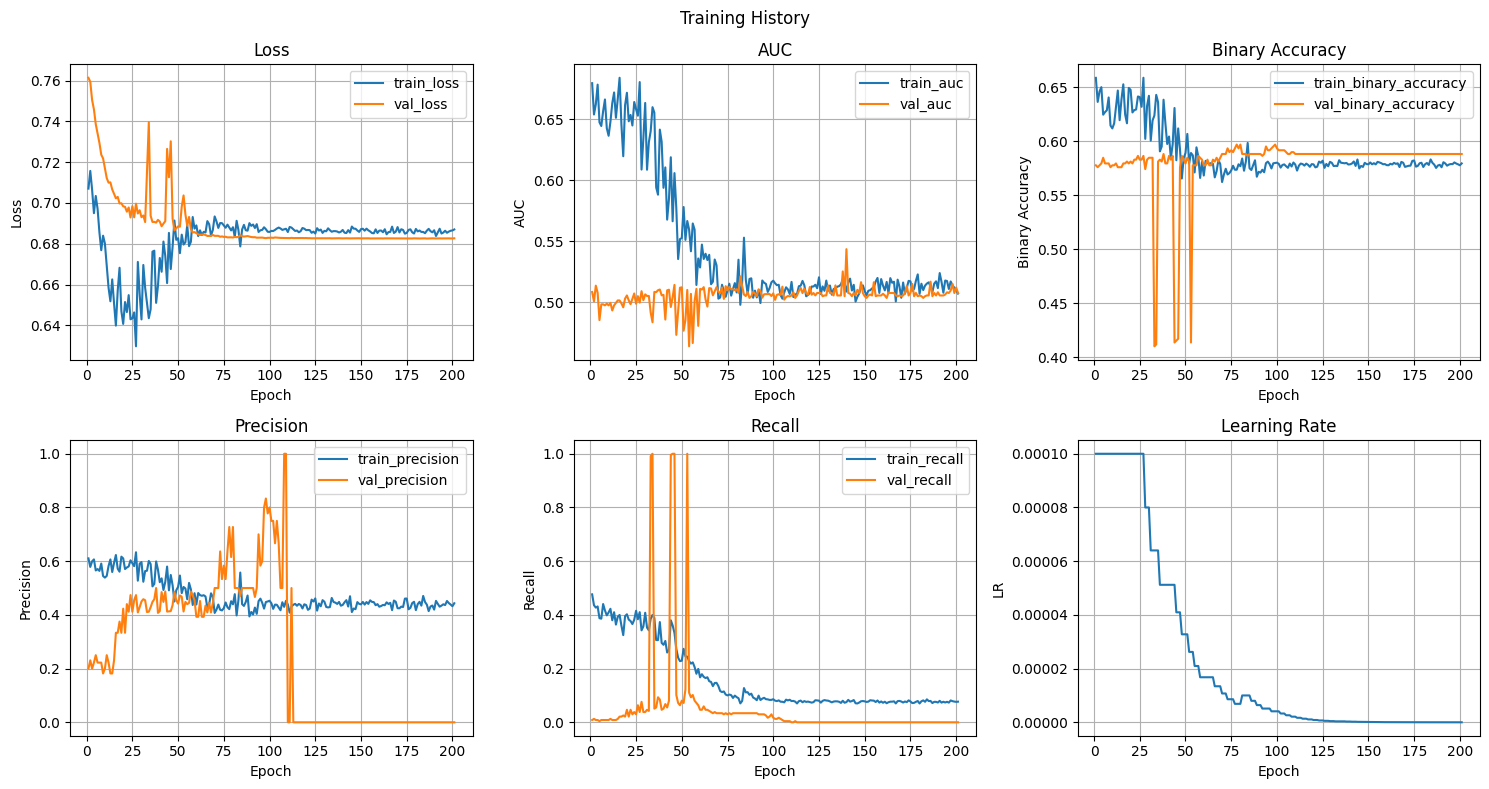

In [25]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [26]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_efficientnetv2-s/initial_ensemble_efficientnetv2-s_efficientnetv2-s_image_random.csv'

#### Split by Patient ID

In [27]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [28]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["low_memory_dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [29]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("efficientnetv2-s")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [30]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


1264/1264 [==============================] - 29s 18ms/step - loss: 0.7100 - auc_1: 0.6734 - binary_accuracy: 0.6625 - precision_1: 0.6049 - recall_1: 0.4764 - val_loss: 0.7481 - val_auc_1: 0.5017 - val_binary_accuracy: 0.6063 - val_precision_1: 0.6000 - val_recall_1: 0.0142 - lr: 1.0000e-04
Epoch 2/80
1264/1264 [==============================] - 18s 14ms/step - loss: 0.7105 - auc_1: 0.6620 - binary_accuracy: 0.6396 - precision_1: 0.5695 - recall_1: 0.4447 - val_loss: 0.7440 - val_auc_1: 0.5040 - val_binary_accuracy: 0.6063 - val_precision_1: 0.5714 - val_recall_1: 0.0189 - lr: 1.0000e-04
Epoch 3/80
1264/1264 [==============================] - 17s 14ms/step - loss: 0.7062 - auc_1: 0.6620 - binary_accuracy: 0.6359 - precision_1: 0.5644 - recall_1: 0.4358 - val_loss: 0.7395 - val_auc_1: 0.5170 - val_binary_accuracy: 0.6045 - val_precision_1: 0.5000 - val_recall_1: 0.0189 - lr: 1.0000e-04
Epoch 4/80
1264/1264 [==============================] - 18s 14ms/step - loss: 0.7085 - auc_1: 0.6444 -

In [31]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
   7/1264 [..............................] - ETA: 22s - loss: 0.6470 - auc_1: 0.0000e+00 - binary_accuracy: 0.7500 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

1264/1264 [==============================] - 19s 15ms/step - loss: 0.6885 - auc_1: 0.5029 - binary_accuracy: 0.5803 - precision_1: 0.4177 - recall_1: 0.0965 - val_loss: 0.6771 - val_auc_1: 0.5044 - val_binary_accuracy: 0.6026 - val_precision_1: 0.3333 - val_recall_1: 0.0047 - lr: 1.0000e-05
Epoch 2/80
1264/1264 [==============================] - 18s 15ms/step - loss: 0.6852 - auc_1: 0.5158 - binary_accuracy: 0.5878 - precision_1: 0.4515 - recall_1: 0.0910 - val_loss: 0.6773 - val_auc_1: 0.5036 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 1.0000e-05
Epoch 3/80
1264/1264 [==============================] - 19s 15ms/step - loss: 0.6820 - auc_1: 0.5279 - binary_accuracy: 0.5919 - precision_1: 0.4735 - recall_1: 0.0854 - val_loss: 0.6773 - val_auc_1: 0.4995 - val_binary_accuracy: 0.6063 - val_precision_1: 1.0000 - val_recall_1: 0.0047 - lr: 1.0000e-05
Epoch 4/80
1264/1264 [==============================] - ETA: 0s - loss: 0.6820 - auc_1: 0.5315

In [32]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
   7/1264 [..............................] - ETA: 23s - loss: 0.5625 - auc_1: 0.0000e+00 - binary_accuracy: 0.9821 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

1264/1264 [==============================] - 20s 15ms/step - loss: 0.6836 - auc_1: 0.5232 - binary_accuracy: 0.5912 - precision_1: 0.4629 - recall_1: 0.0702 - val_loss: 0.6784 - val_auc_1: 0.4797 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 3.2768e-06
Epoch 2/80
1264/1264 [==============================] - 19s 15ms/step - loss: 0.6837 - auc_1: 0.5176 - binary_accuracy: 0.5879 - precision_1: 0.4329 - recall_1: 0.0628 - val_loss: 0.6784 - val_auc_1: 0.4812 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 3.2768e-06
Epoch 3/80
1264/1264 [==============================] - 20s 16ms/step - loss: 0.6822 - auc_1: 0.5255 - binary_accuracy: 0.5931 - precision_1: 0.4786 - recall_1: 0.0726 - val_loss: 0.6784 - val_auc_1: 0.4829 - val_binary_accuracy: 0.6045 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - lr: 3.2768e-06
Epoch 4/80
1262/1264 [============================>.] - ETA: 0s - loss: 0.6831

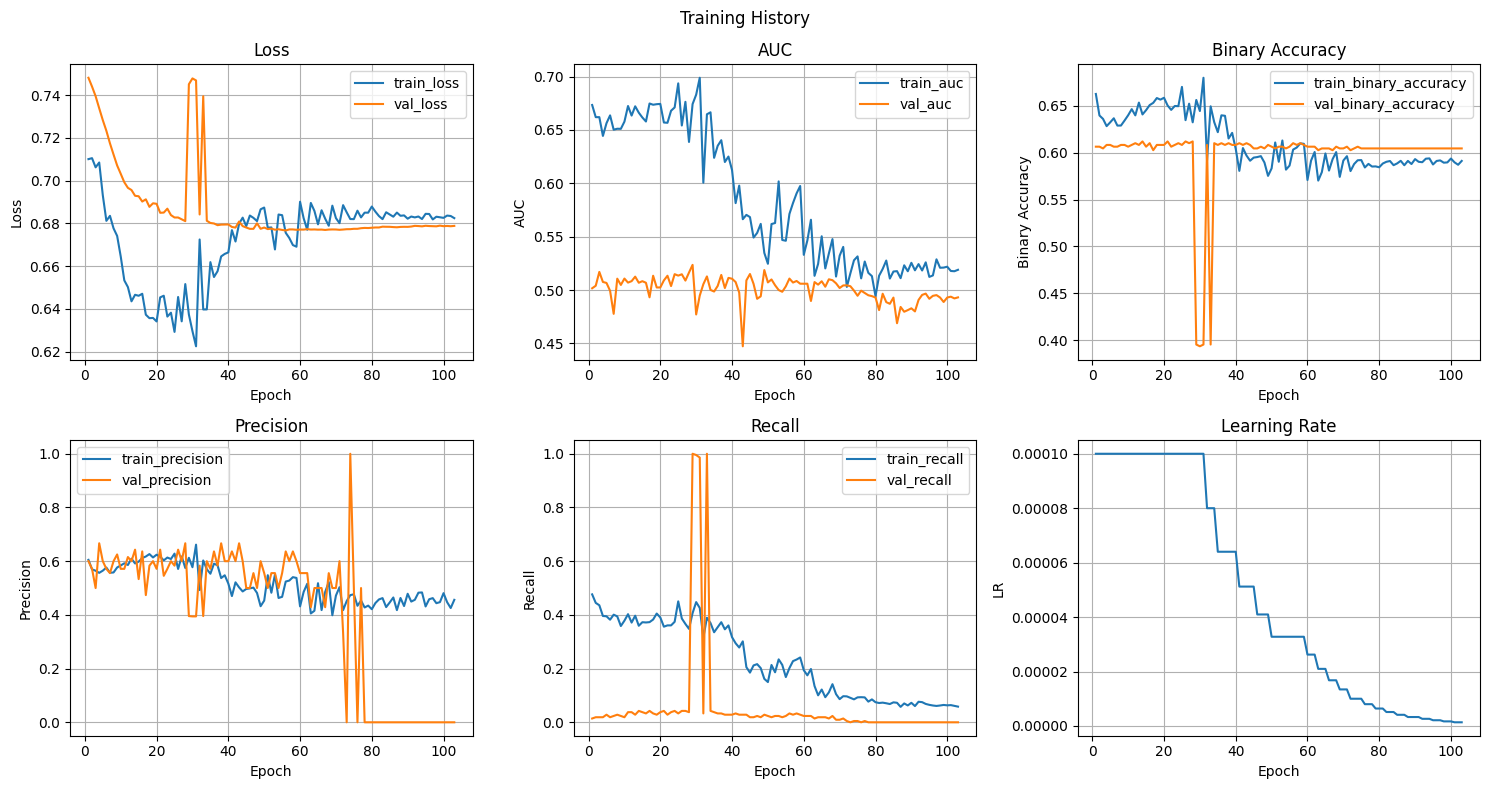

In [33]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [34]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_efficientnetv2-s/initial_ensemble_efficientnetv2-s_efficientnetv2-s_patient_random.csv'